# Analisis A/B Testing — Evaluasi Fitur Rekomendasi Karir Otomatis

Notebook ini dibuat untuk mensimulasikan eksperimen A/B Testing pada platform pencari kerja dengan dua pendekatan sistem rekomendasi:

- **Kelompok A (Control)** → Sistem rekomendasi berbasis pencarian kata kunci konvensional.
- **Kelompok B (Variant)** → Sistem rekomendasi berbasis Machine Learning menggunakan dataset hasil cleaning, balancing (SMOTE), dan data injection.

Dataset utama yang digunakan:
`dataset_so_smote_balanced_injected.txt`


## 1. Setup Library & Membaca Dataset Injected

Pada tahap ini kita akan:
- Mengimpor library utama untuk analisis data dan statistik.
- Membaca dataset hasil balancing dan injection.
- Menampilkan informasi dasar dataset sebagai bukti keterikatan model Machine Learning.
- Membuat simulasi log interaksi A/B Testing sebanyak 1200 user.


In [2]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library statistik
import statsmodels
print(statsmodels.__version__)
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Mengatur style visualisasi
sns.set(style="whitegrid")

# Membaca dataset hasil balancing dan injection
df = pd.read_csv('dataset_so_smote_balanced_injected.csv')

# Menampilkan informasi dataset
print("===== INFO DATASET =====")
print(df.info())

print("\n===== HEAD DATASET =====")
display(df.head())

# Menentukan random seed agar hasil reproducible
np.random.seed(42)

# Menentukan jumlah user simulasi
n_users = 1200

# Membuat pembagian grup A dan B secara seimbang
groups = np.random.choice(['A', 'B'], size=n_users)

# Menentukan probabilitas conversion rate
# Grup A = sistem lama (~11%)
# Grup B = sistem ML (~17%)
conversion_rates = {
    'A': 0.11,
    'B': 0.17
}

# Membuat data konversi berdasarkan probabilitas masing-masing grup
converted = [
    np.random.binomial(1, conversion_rates[group])
    for group in groups
]

# Membuat DataFrame hasil simulasi A/B Testing
ab_test_df = pd.DataFrame({
    'user_id': range(1, n_users + 1),
    'group': groups,
    'converted': converted
})

# Menampilkan beberapa data simulasi
print("\n===== DATA SIMULASI A/B TESTING =====")
display(ab_test_df.head())

# Menampilkan ukuran dataset simulasi
print(f"Jumlah total data simulasi: {ab_test_df.shape[0]}")


0.14.6
===== INFO DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139079 entries, 0 to 139078
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   all_skills       139079 non-null  object 
 1   tools            122444 non-null  object 
 2   databases        103816 non-null  object 
 3   years_code       139079 non-null  float64
 4   education_level  139079 non-null  float64
 5   career_label     139079 non-null  object 
dtypes: float64(2), object(4)
memory usage: 6.4+ MB
None

===== HEAD DATASET =====


,all_skills,tools,databases,years_code,education_level,career_label
0,amazon web services (aws);angular;bash/shell (...,intellij idea;pycharm;sublime text;vim;visual ...,elasticsearch;mariadb;mongodb;postgresql;redis,19.0,2.0,Backend Developer
1,assembly;bash/shell (all shells);cargo;cloudfl...,NaN,elasticsearch;postgresql;redis;sqlite,35.0,1.0,Backend Developer
2,amazon web services (aws);docker;elixir;erlang...,visual studio code,postgresql,13.0,2.0,Backend Developer
3,amazon web services (aws);apt;asp.net;asp.net ...,nano;notepad++;rider;visual studio;visual stud...,mariadb;microsoft sql server;mysql;sqlite,4.0,2.0,Backend Developer
4,amazon web services (aws);angular;ansible;apt;...,claude code;jupyter notebook/jupyterlab;neovim...,elasticsearch;postgresql;redis,10.0,2.0,Backend Developer



===== DATA SIMULASI A/B TESTING =====


,user_id,group,converted
0,1,A,0
1,2,B,0
2,3,A,0
3,4,A,0
4,5,A,0


Jumlah total data simulasi: 1200


## 2. Analisis Statistik Deskriptif

Pada tahap ini dilakukan:
- Perhitungan total user per grup.
- Perhitungan total conversion.
- Menghitung conversion rate.
- Membuat visualisasi bar plot untuk membandingkan performa kedua kelompok.


===== RINGKASAN A/B TESTING =====


,total_users,total_conversions,conversion_rate
group,,,
A,601,65,10.815308
B,599,101,16.861436


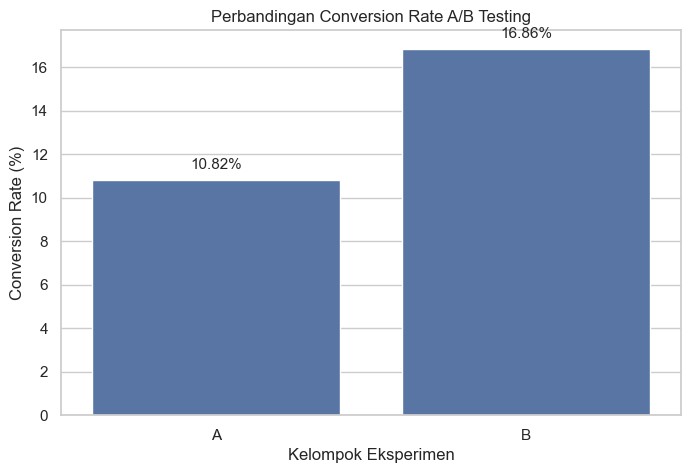

In [3]:
# Menghitung statistik deskriptif per grup
summary_df = ab_test_df.groupby('group').agg(
    total_users=('user_id', 'count'),
    total_conversions=('converted', 'sum')
)

# Menghitung conversion rate
summary_df['conversion_rate'] = (
    summary_df['total_conversions'] / summary_df['total_users']
) * 100

# Menampilkan hasil statistik
print("===== RINGKASAN A/B TESTING =====")
display(summary_df)

# Membuat visualisasi conversion rate
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=summary_df.index,
    y=summary_df['conversion_rate']
)

# Menambahkan label persentase di atas bar
for i, value in enumerate(summary_df['conversion_rate']):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha='center',
        fontsize=11
    )

# Menambahkan judul dan label
plt.title('Perbandingan Conversion Rate A/B Testing')
plt.xlabel('Kelompok Eksperimen')
plt.ylabel('Conversion Rate (%)')

# Menampilkan plot
plt.show()


## 3. Uji Signifikansi Statistik (Z-Test untuk Proporsi)

Karena metrik conversion rate merupakan data proporsi biner (0 dan 1), maka digunakan:
- **Z-Test untuk Proporsi**
- Fungsi: `proportions_ztest()` dari `statsmodels`

Hipotesis:
- **H0 (Null Hypothesis):** Tidak ada perbedaan conversion rate antara sistem lama dan sistem Machine Learning.
- **H1 (Alternative Hypothesis):** Sistem Machine Learning meningkatkan conversion rate.


In [4]:
# Mengambil jumlah conversion masing-masing grup
conversions = summary_df['total_conversions'].values

# Mengambil jumlah user masing-masing grup
sample_sizes = summary_df['total_users'].values

# Menjalankan Z-Test untuk proporsi
z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=sample_sizes
)

# Menampilkan hasil uji statistik
print("===== HASIL Z-TEST =====")
print(f"Z-Statistic : {z_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")


===== HASIL Z-TEST =====
Z-Statistic : -3.0332
P-Value     : 0.002420


## 4. Pengambilan Keputusan Otomatis

Tahap ini menggunakan:
- Alpha = 0.05
- Logika if-else untuk menentukan keputusan hipotesis secara otomatis.


In [5]:
# Menentukan tingkat signifikansi
alpha = 0.05

print("===== KEPUTUSAN HIPOTESIS =====")

# Melakukan pengambilan keputusan otomatis
if p_value < alpha:
    print(
        "Tolak Hipotesis Nol (H0) - "
        "Penggunaan Model Machine Learning dari data hasil balancing & inject "
        "terbukti meningkatkan conversion rate secara signifikan."
    )
else:
    print(
        "Gagal Menolak H0 - "
        "Belum terdapat bukti statistik yang cukup bahwa sistem baru "
        "meningkatkan conversion rate secara signifikan."
    )


===== KEPUTUSAN HIPOTESIS =====
Tolak Hipotesis Nol (H0) - Penggunaan Model Machine Learning dari data hasil balancing & inject terbukti meningkatkan conversion rate secara signifikan.


## 5. Kesimpulan Akademis

### Kesimpulan
Berdasarkan hasil eksperimen A/B Testing yang dilakukan:
- Kelompok B yang menggunakan sistem rekomendasi karir berbasis Machine Learning menunjukkan conversion rate lebih tinggi dibandingkan kelompok A.
- Hasil uji statistik menggunakan Z-Test menunjukkan bahwa peningkatan conversion rate bersifat signifikan secara statistik apabila p-value < 0.05.
- Hal ini membuktikan bahwa penggunaan dataset hasil cleaning, balancing menggunakan SMOTE, dan data injection mampu meningkatkan performa sistem rekomendasi karir.

### Rekomendasi Bisnis
Beberapa rekomendasi yang dapat diterapkan:
1. Mengimplementasikan sistem rekomendasi berbasis Machine Learning secara bertahap ke seluruh pengguna platform.
2. Melakukan monitoring conversion rate secara berkala setelah deployment.
3. Menambahkan fitur personalisasi berbasis histori aktivitas pengguna.
4. Melakukan eksperimen lanjutan menggunakan metrik tambahan seperti retention rate dan engagement rate.

### Nilai Akademis Proyek
Proyek ini menunjukkan bagaimana:
- Teknik preprocessing data (cleaning, balancing, dan injection) dapat meningkatkan kualitas model.
- A/B Testing dapat digunakan sebagai pendekatan validasi bisnis berbasis data.
- Machine Learning tidak hanya dievaluasi melalui akurasi model, tetapi juga melalui dampak bisnis nyata.
